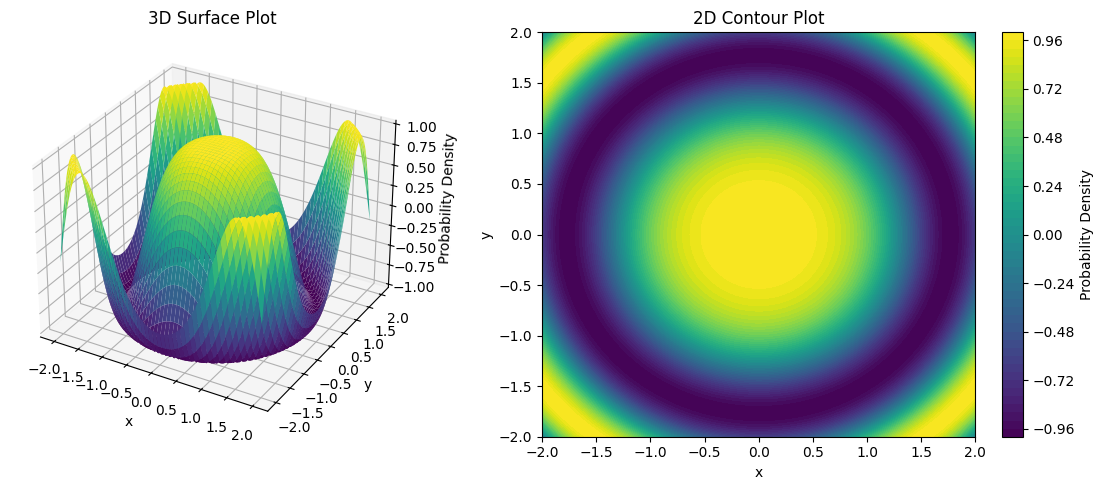

In [1]:
# Solve SchrÃ¶dinger equation for a 2D system
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)
Z = np.cos(-1*(X**2 + Y**2))

fig = plt.figure(figsize=(12, 5))

ax3d = fig.add_subplot(1, 2, 1, projection="3d")
ax3d.plot_surface(X, Y, Z, cmap="viridis")
ax3d.set_title("3D Surface Plot")
ax3d.set_xlabel("x")
ax3d.set_ylabel("y")
ax3d.set_zlabel("Probability Density")

ax2d = fig.add_subplot(1, 2, 2)
contour = ax2d.contourf(X, Y, Z, levels=50, cmap="viridis")
ax2d.set_title("2D Contour Plot")
ax2d.set_xlabel("x")
ax2d.set_ylabel("y")
fig.colorbar(contour, ax=ax2d, label="Probability Density")

fig.tight_layout()
plt.show()

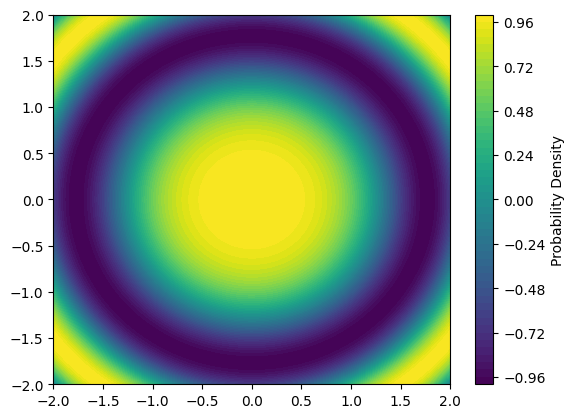

In [2]:
plt.contourf(X, Y, Z, levels=50, cmap="viridis")
plt.colorbar(label="Probability Density")
plt.show()

In [3]:
import numpy as np
from scipy.sparse.linalg import eigsh
from scipy.sparse.linalg import eigs
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import PillowWriter
import scienceplots
plt.style.use(['science', 'notebook'])
from scipy import sparse

Create a meshgrid of $x$ and $y$ coordinates

In [4]:
N = 400
X, Y = np.mgrid[0:1:N*1j,0:1:N*1j]

Eigenstates of the time-independent Schroedinger equation satisfy $\hat{H}\psi = E\psi$ where $\hat{H}$ is the Hamiltonian operator, and $E$ and $\psi$ represent the eigenvalues/eigenstates. The Hamiltonian Operator in 2D is
$$\hat{H} = -\frac{1}{2m} (\partial^2_x + \partial^2_y) + V(x,y).$$
If we discretize $\psi$ into a vector (spacing $\Delta x$), the equation $\hat{H}\psi = E\psi$ can be arranged and rewritten in 2 dimensions as
$$\left[ -\frac{1}{2m \Delta x^2} (\hat{D} \oplus \hat{D}) +  V\right]\psi = E\psi,$$
where
    - $\psi$ is a vector of length $N^2$ where $N$ is the number of discretized points in $x$ and $y$,
    - $\hat{D}$ is an $N \times N$ matrix,
    - $D \oplus D$ is a tridiagonal $N^2 \times N^2$ matrix with -2 on the main diagonal and 1 on the two neighbouring diagonals. $\oplus$ represents the Kronecker sum of two matrices,    
    - $V$ is a diagonal $N^2 \times N^2$ matrix with each entry on the diagonal representative of the potential at that particular coordinate.

In [5]:

def get_potential(x, y):
    return np.exp(-(x-0.3)**2/(2*0.1**2))*np.exp(-(y-0.3)**2/(2*0.1**2))
V = get_potential(X,Y)

In [6]:

diag = np.ones([N])
diags = np.array([diag, -2*diag, diag])
D = sparse.spdiags(diags, np.array([-1,0,1]), N, N)
T = -1/2 * sparse.kronsum(D,D)
U = sparse.diags(V.reshape(N**2), (0))
H = T+U

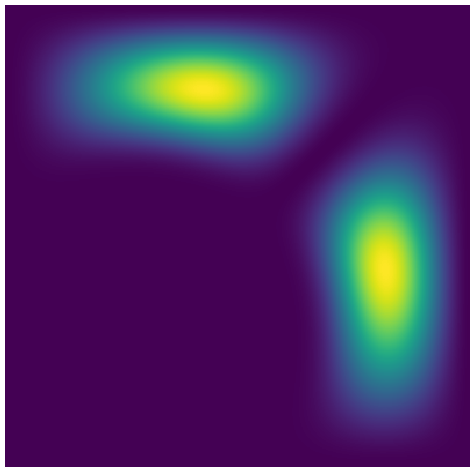

In [8]:
eigenvalues, eigenvectors = eigsh(H, k=10, which='SM')

def get_e(n):
    return eigenvectors.T[n].reshape((N,N))

plt.figure(figsize=(6,6))
plt.pcolormesh(X, Y, get_e(1)**2, cmap='viridis')
plt.axis('off')
plt.show()